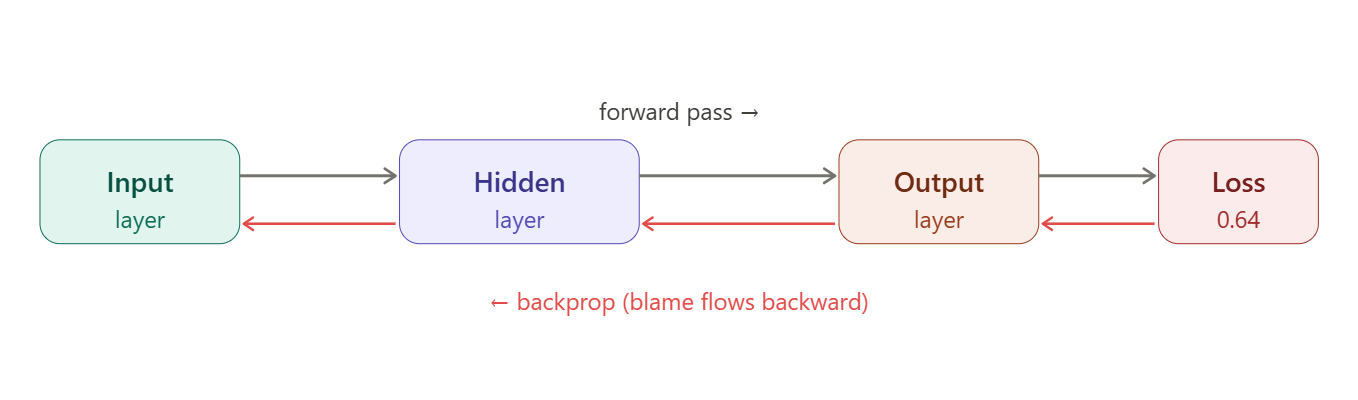

In [1]:
import torch
import torch.nn as nn

# Build
model = nn.Sequential(
    nn.Linear(3, 8),
    nn.ReLU(),
    nn.Linear(8, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

# One person: [heat=9, mood=7, money=1]
person = torch.tensor([[9.0, 7.0, 1.0]])

# Forward pass — data flows through every layer left to right
output = model(person)
print(f"Probability of buying: {output.item():.0%}")

Probability of buying: 45%


In [2]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(3, 8), nn.ReLU(),
    nn.Linear(8, 1), nn.Sigmoid()
)

loss_fn   = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Fake training data: [heat, mood, money] → bought ice cream?
X = torch.tensor([[9.0, 7.0, 1.0], [2.0, 3.0, 0.0], [8.0, 8.0, 1.0]])
y = torch.tensor([[1.0],            [0.0],             [1.0]])

for epoch in range(100):            # 100 rounds of learning
    # 1. Forward pass — make prediction
    prediction = model(X)

    # 2. Measure loss — how wrong are we?
    loss = loss_fn(prediction, y)

    # 3. Backward pass — who's to blame?
    optimizer.zero_grad()           # clear old gradients first
    loss.backward()                 # compute new gradients

    # 4. Update weights — fix the mistakes
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# Loss should go down each time — network is getting smarter

Epoch 0 | Loss: 2.1374
Epoch 20 | Loss: 0.4287
Epoch 40 | Loss: 0.4168
Epoch 60 | Loss: 0.4073
Epoch 80 | Loss: 0.3984


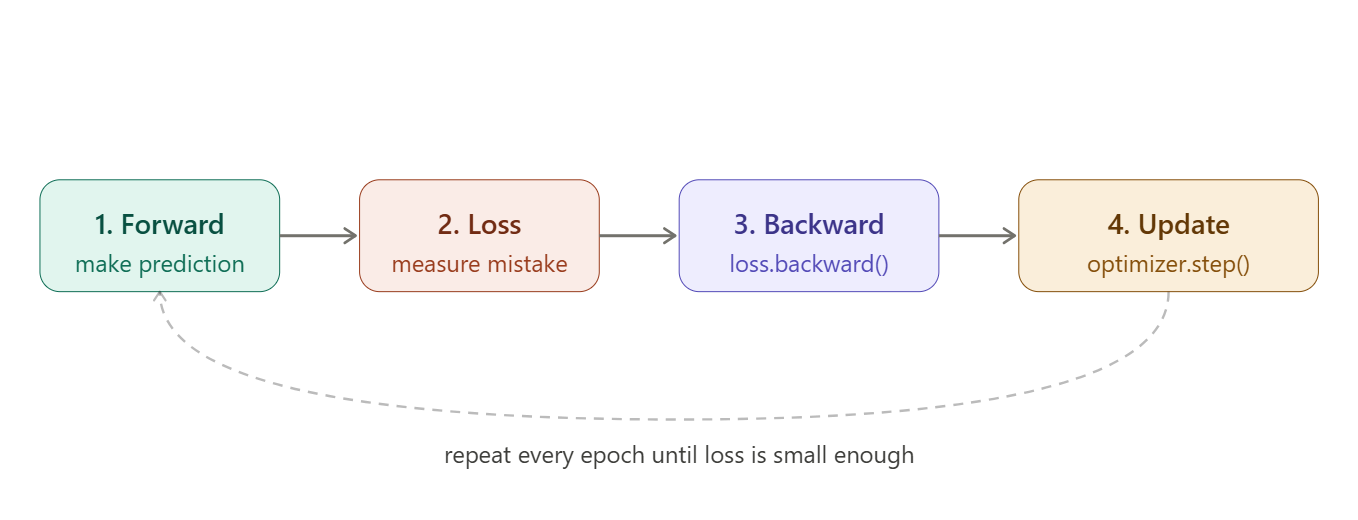